In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, mean_squared_error

In [5]:
# Load dataset
data = pd.read_csv('loan_data.csv')

In [7]:
# Display basic information
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [9]:
# convert to age to int format
data['person_age'] = data['person_age'].astype('int')
data['person_age'].dtypes

dtype('int32')

In [11]:
cat_cols = [var for var in data.columns if data[var].dtypes == 'object']
num_cols = [var for var in data.columns if data[var].dtypes != 'object']

print(f'Categorical columns: {cat_cols}')
print(f'Numerical columns: {num_cols}')

Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


In [13]:
print(data.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0          22        female           Master        71948.0               0   
1          21        female      High School        12282.0               0   
2          25        female      High School        12438.0               3   
3          23        female         Bachelor        79753.0               0   
4          24          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [15]:
print(data.shape)

(45000, 14)


In [17]:
# Display the number of unique values in each column
print("\nUnique Values in Each Column:")
print(data.nunique())


Unique Values in Each Column:
person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64


In [19]:
# Summary statistics
print(data.describe())

         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.704800e+04        4.000000   8000.000000   
75%       30.000000   9.578925e+04        8.000000  12237.250000   
max      144.000000   7.200766e+06      125.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   45000.000000         45000.000000                45000.000000   
mean       11.006606             0.139725                    5.867489   
std         2.978808             0.087212                    3.879702   
min         5.420000             0.000000                    2.000000   
25%         8.590000  

In [21]:
bins = [18,25, 35, 50]
age_category = ['teen', 'adult','mature adult']
data['age_category'] = pd.cut(data['person_age'], bins=bins, labels=age_category)
data['age_category']

0                teen
1                teen
2                teen
3                teen
4                teen
             ...     
44995           adult
44996    mature adult
44997           adult
44998           adult
44999            teen
Name: age_category, Length: 45000, dtype: category
Categories (3, object): ['teen' < 'adult' < 'mature adult']

In [23]:
# Handle anomalies (e.g., person_age > 100)
data = data[data['person_age'] <= 100]

# Replace extreme outliers in income with the 99th percentile
income_cap = np.percentile(data['person_income'], 99)
data['person_income'] = np.where(data['person_income'] > income_cap, income_cap, data['person_income'])

# Check missing values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
person_age                          0
person_gender                       0
person_education                    0
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                           0
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                        0
previous_loan_defaults_on_file      0
loan_status                         0
age_category                      321
dtype: int64


In [25]:
# Convert categorical columns to numerical
data['person_gender'] = data['person_gender'].map({'male': 1, 'female': 0})
data['previous_loan_defaults_on_file'] = data['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

# Check the cleaned data
print(data.head())



   person_age  person_gender person_education  person_income  person_emp_exp  \
0          22              0           Master        71948.0               0   
1          21              0      High School        12282.0               0   
2          25              0      High School        12438.0               3   
3          23              0         Bachelor        79753.0               0   
4          24              1           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0          

In [27]:
demography = data.groupby(['age_category', 'person_gender'], as_index=False)['person_income'].mean()
demography

#Insight: This table shows that as age category increases from teen to mature adult, the average income also increases

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\2737532284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demography = data.groupby(['age_category', 'person_gender'], as_index=False)['person_income'].mean()


,age_category,person_gender,person_income
0,teen,0,70781.877870
1,teen,1,71214.327825
2,adult,0,82368.307371
3,adult,1,84063.360890
4,mature adult,0,86033.701791
5,mature adult,1,86337.980986


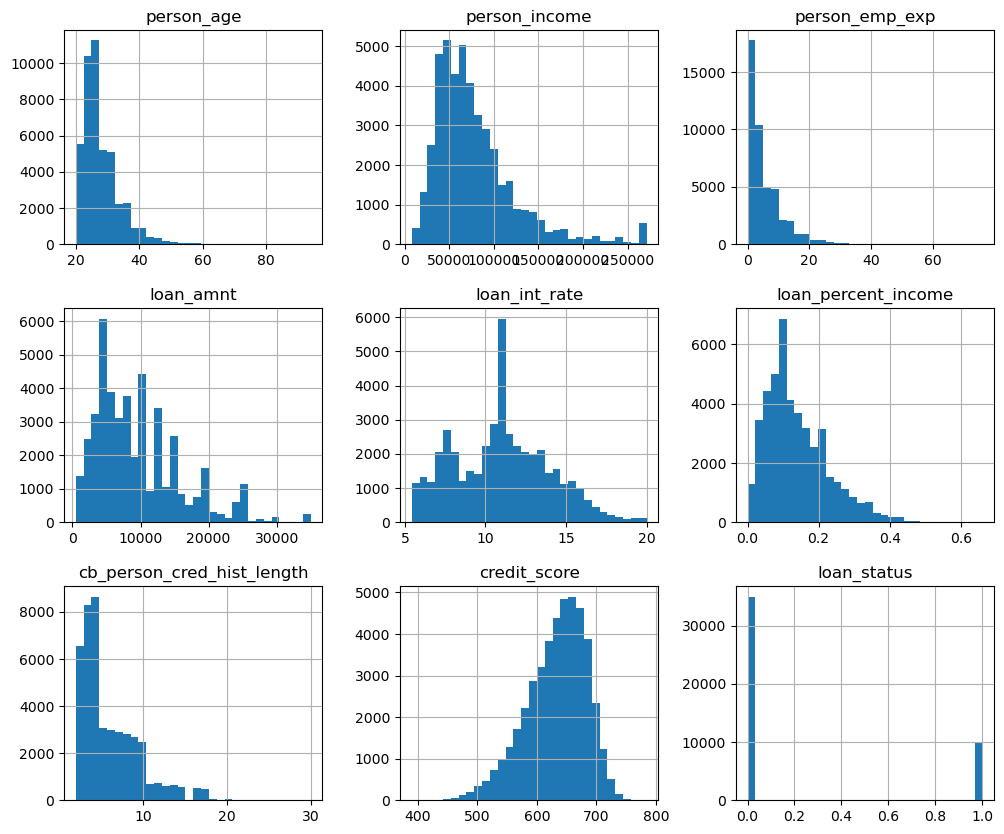

In [29]:
data[num_cols].hist(bins=30, figsize=(12,10))
plt.show()

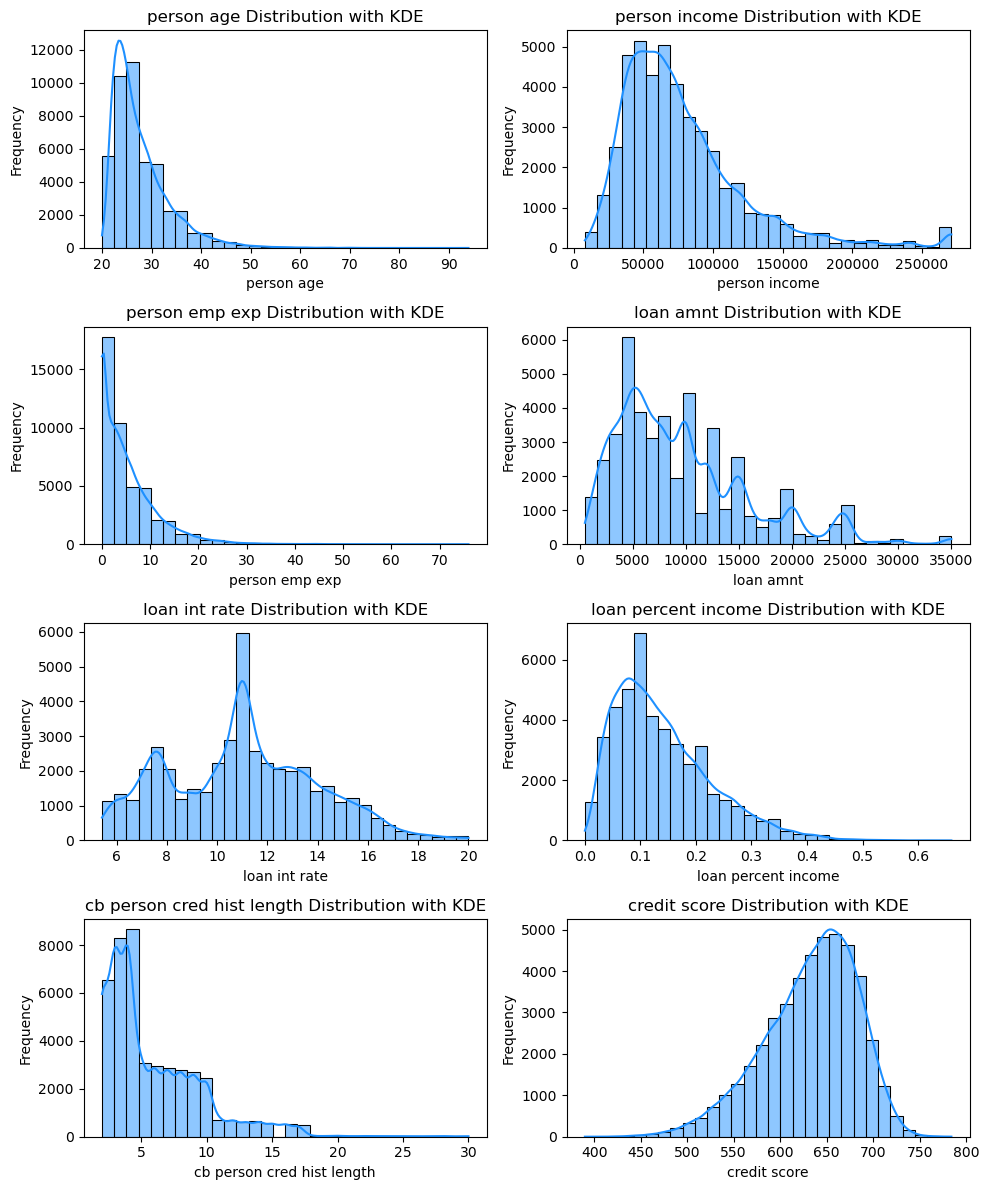

In [31]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(10, 12))  
    
    for i, column in enumerate(columns, 1):
        plt.subplot(4, 2, i)  
        sns.histplot(data[column], kde=True, bins=30, color='dodgerblue')
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

columns_to_analyze = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

univariate_analysis(data, columns_to_analyze)

In [35]:
def plot_categorical_distribution(column_name, data=data):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=data, palette='muted')  
    plt.title(f'Distribution of {column_name}')
    
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2), 
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')
    
    sns.despine(left=True, bottom=True)
    
    plt.subplot(1, 2, 2)
    data[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*data[column_name].nunique())
    plt.title(f'Percentage Distribution of {column_name}')
    plt.ylabel('')  
    
    plt.tight_layout()
    plt.show()

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3313789965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


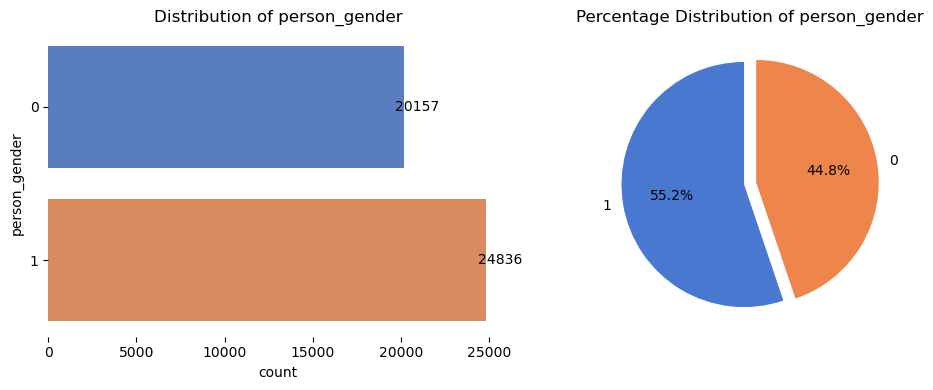

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3313789965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


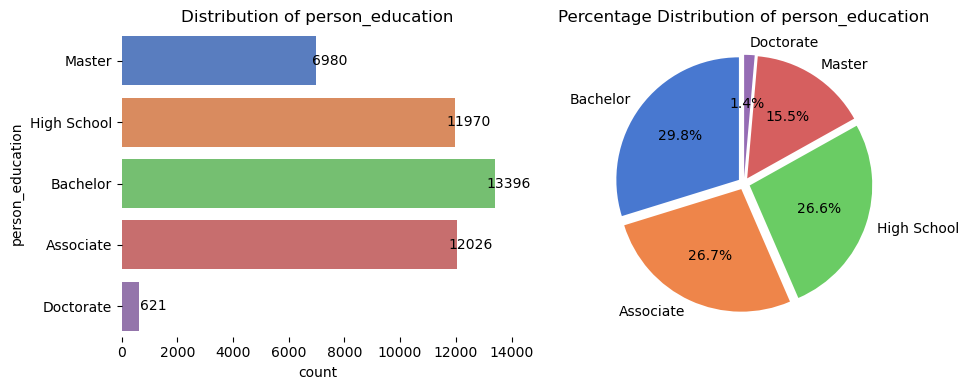

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3313789965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


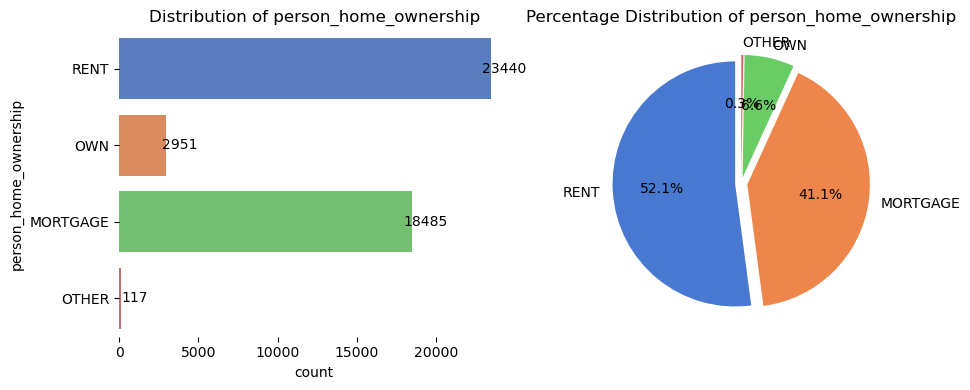

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3313789965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


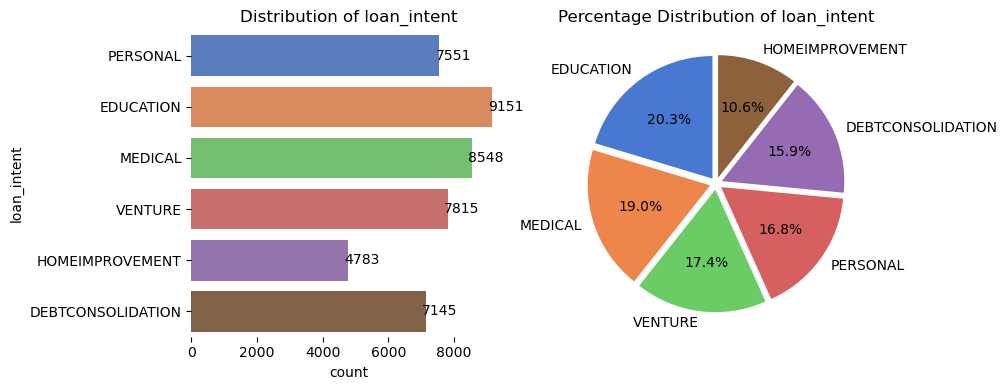

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3313789965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=column_name, data=data, palette='muted')


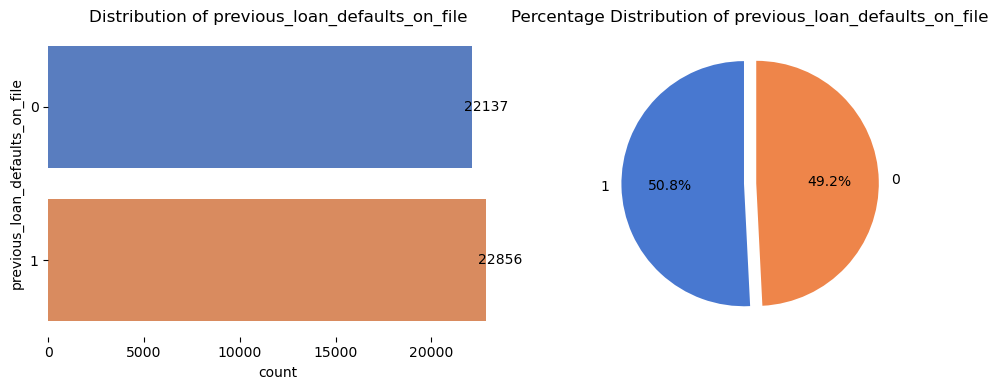

In [37]:
plot_categorical_distribution('person_gender')
plot_categorical_distribution('person_education')
plot_categorical_distribution('person_home_ownership')
plot_categorical_distribution('loan_intent')
plot_categorical_distribution('previous_loan_defaults_on_file')

In [39]:
print(demography['age_category'].unique())

['teen', 'adult', 'mature adult']
Categories (3, object): ['teen' < 'adult' < 'mature adult']


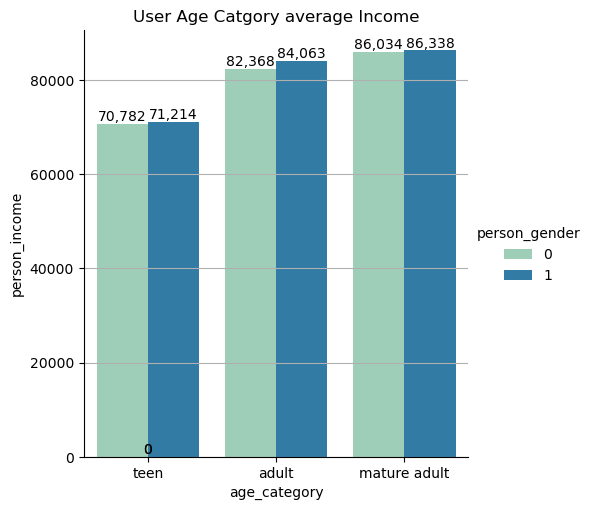

In [41]:
dg = sns.catplot(demography, kind='bar', x='age_category', y='person_income', hue='person_gender', palette='YlGnBu')
ax = dg.ax
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 1500,
        f'{p.get_height():,.0f}',
        ha='center',
        va='center',
        fontsize=10
    )
plt.grid(axis='y')
plt.title('User Age Catgory average Income')
plt.show()

In [43]:
edu = data.groupby(['person_education','person_home_ownership'], as_index=False)['loan_amnt'].mean()
edu

,person_education,person_home_ownership,loan_amnt
0,Associate,MORTGAGE,10799.832897
1,Associate,OTHER,10747.342857
2,Associate,OWN,9039.829602
3,Associate,RENT,8763.263826
4,Bachelor,MORTGAGE,10571.113950
5,Bachelor,OTHER,11590.853659
6,Bachelor,OWN,9023.180328
7,Bachelor,RENT,8826.527479
8,Doctorate,MORTGAGE,11482.035714
9,Doctorate,OTHER,20000.000000


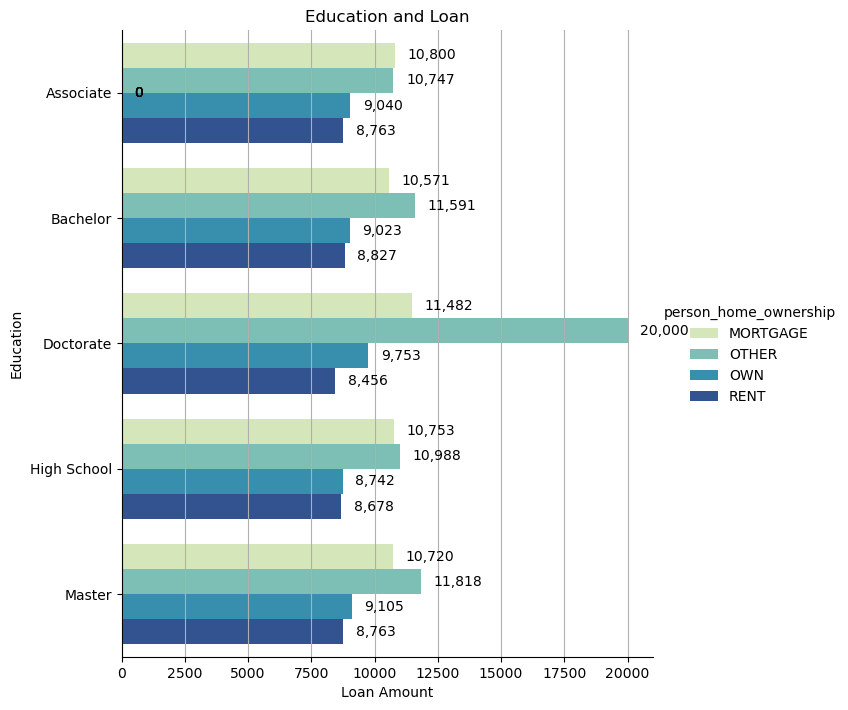

In [45]:
ed = sns.catplot(edu, x='loan_amnt', y='person_education', hue='person_home_ownership', kind='bar', height=7, palette='YlGnBu')
ax = ed.ax
for p in ax.patches:
    ax.text(
        p.get_width() + 500,  # Position text slightly to the right of the bar
        p.get_y() + p.get_height() / 2,  # Center text vertically
        f'{p.get_width():,.0f}',
        ha='left',
        va='center',
        fontsize=10
    )
plt.title('Education and Loan')
plt.xlabel("Loan Amount")
plt.ylabel('Education')
plt.grid(axis='x')

#This plot shows Doctorate degree holders with "OTHER" home ownership having the highest average loan amount of $20000.


In [47]:
loan_usage = data.groupby('loan_intent')['loan_intent'].count()
intent_label = ['DEBTCONSOLIDATION','EDUCATION','HOMEIMPROVEMENT','MEDICAL','PERSONAL','VENTURE']
c_map = ['#f7fcf0', '#ccebc5', '#a8ddb5', '#7bccc4', '#43a2ca', '#0868ac']
loan_usage

loan_intent
DEBTCONSOLIDATION    7145
EDUCATION            9151
HOMEIMPROVEMENT      4783
MEDICAL              8548
PERSONAL             7551
VENTURE              7815
Name: loan_intent, dtype: int64

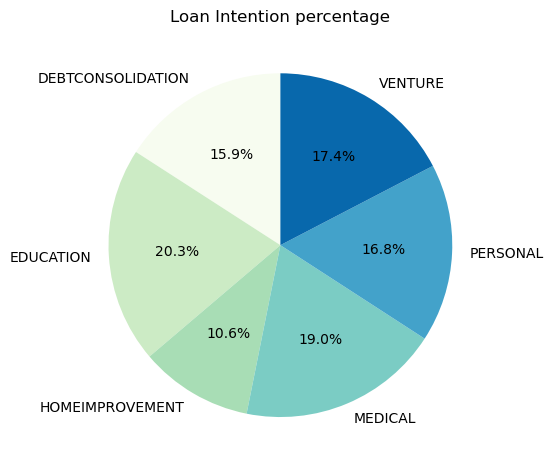

In [49]:
plt.pie(x=loan_usage, labels=intent_label, startangle=90, autopct='%1.1f%%', colors=c_map)
plt.title('Loan Intention percentage')
plt.tight_layout()
plt.show()

In [51]:
loan_correlation = data[['loan_intent']]
loan_correlation['income'] = data['person_income'].apply(lambda x : 2* (x - data['person_income'].min())/(data['person_income'].max()-data['person_income'].min()) -1)
loan_correlation['loan'] = data['loan_amnt'].apply(lambda x : 2* (x - data['loan_amnt'].min())/(data['loan_amnt'].max()-data['loan_amnt'].min()) -1)
loan_correlation

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\1833327375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_correlation['income'] = data['person_income'].apply(lambda x : 2* (x - data['person_income'].min())/(data['person_income'].max()-data['person_income'].min()) -1)
C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\1833327375.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_correlation['loan'] = data['loan_amnt'].apply(lambda x : 2* (x - data['loan_amnt'].min())/(data['loan_amnt'].max()

,loan_intent,income,loan
0,PERSONAL,-0.514197,1.000000
1,EDUCATION,-0.967470,-0.971014
2,MEDICAL,-0.966285,-0.710145
3,MEDICAL,-0.454903,1.000000
4,MEDICAL,-0.558357,1.000000
...,...,...,...
44995,MEDICAL,-0.696346,-0.159420
44996,HOMEIMPROVEMENT,-0.560902,-0.507246
44997,DEBTCONSOLIDATION,-0.628195,-0.868348
44998,EDUCATION,-0.808833,-0.333333


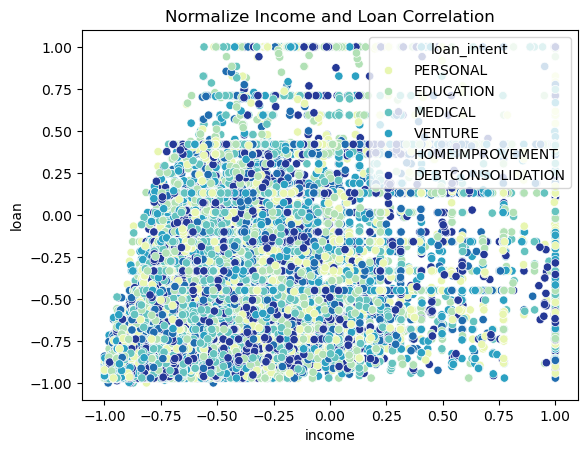

In [55]:
sns.scatterplot(loan_correlation, x='income', y='loan', hue='loan_intent', palette='YlGnBu' )
plt.title('Normalize Income and Loan Correlation')
plt.show()

<Axes: >

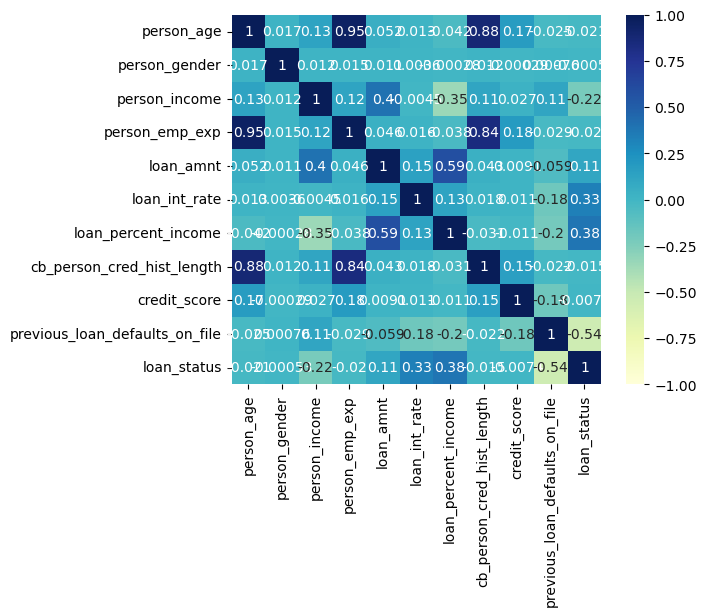

In [57]:
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=True, square=True, center=0, vmin=-1)

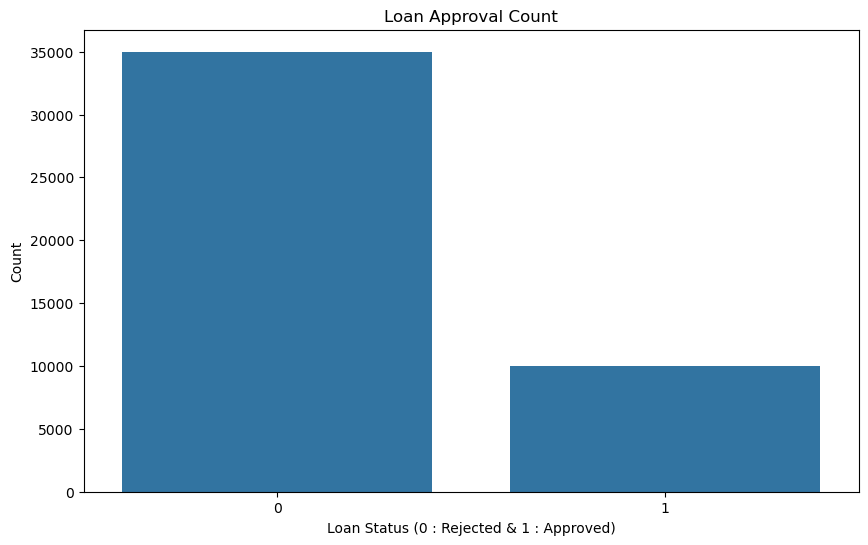

In [59]:
# Loan approval distribution

plt.figure(figsize=(10, 6))

sns.countplot(x='loan_status', data=data)

plt.title('Loan Approval Count')

plt.xlabel('Loan Status (0 : Rejected & 1 : Approved)')

plt.ylabel('Count')

plt.show()

C:\Users\abiyu\AppData\Local\Temp\ipykernel_21720\1972845229.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_intent', data=data, order=data['loan_intent'].value_counts().index, palette="magma")


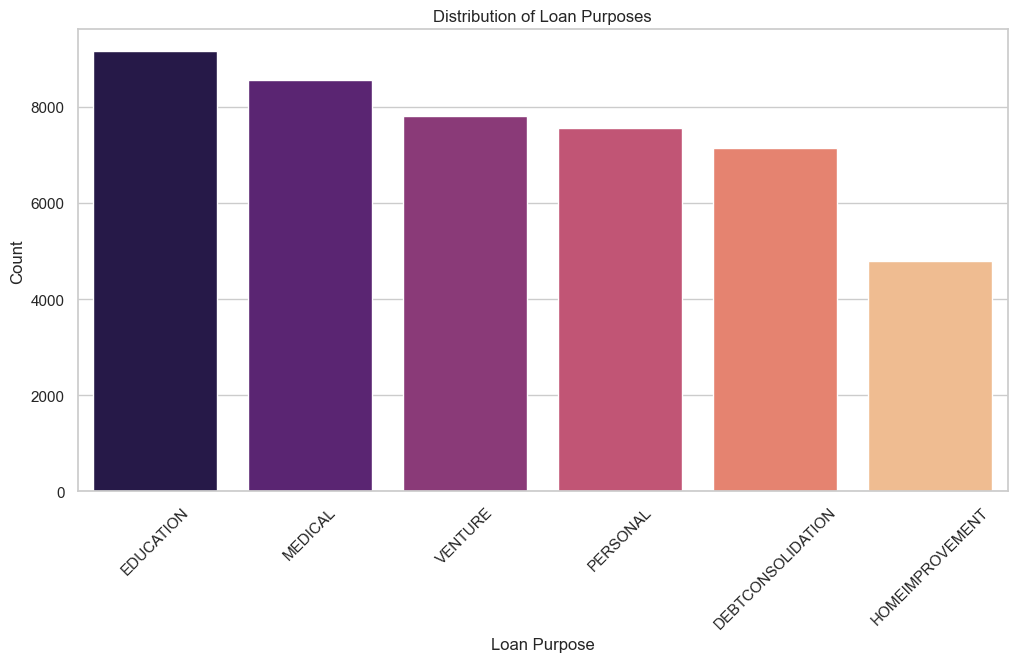

In [206]:
# Set the aesthetic style of the plots

sns.set(style='whitegrid')

# Loan Purpose Distribution

plt.figure(figsize=(12, 6))

sns.countplot(x='loan_intent', data=data, order=data['loan_intent'].value_counts().index, palette="magma")

plt.title('Distribution of Loan Purposes')

plt.xlabel('Loan Purpose')

plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

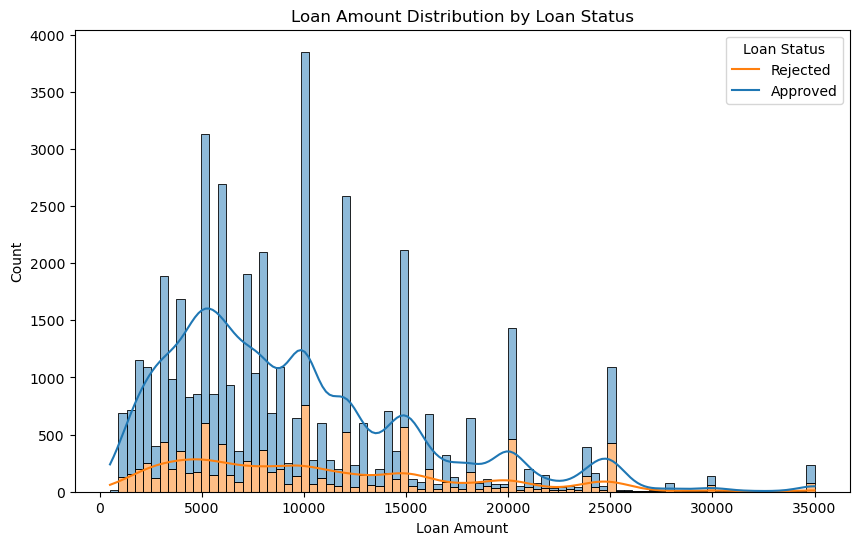

In [61]:
# Loan Amount Distribution by Loan Status

plt.figure(figsize=(10, 6))

sns.histplot(data=data, x='loan_amnt', hue='loan_status', kde=True, multiple='stack')

plt.title('Loan Amount Distribution by Loan Status')

plt.xlabel('Loan Amount')

plt.ylabel('Count')

plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])

plt.show()

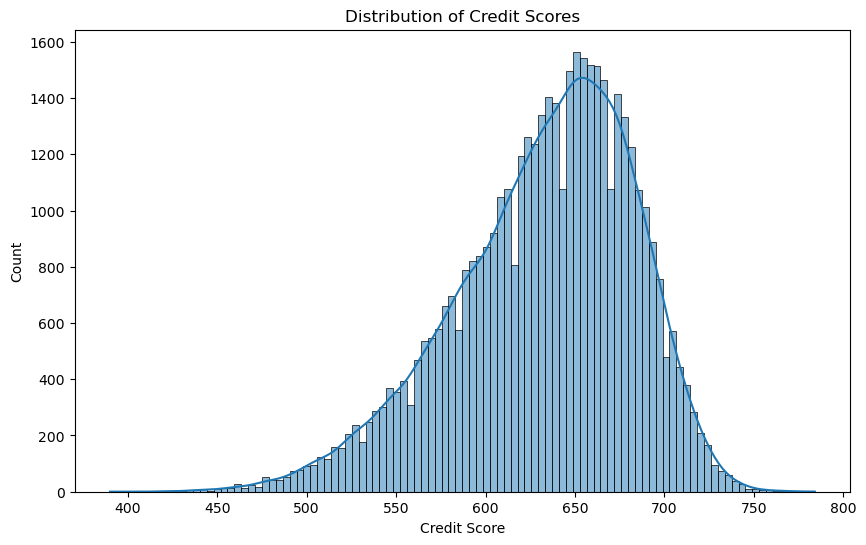

In [63]:
# Credit Score Distribution

plt.figure(figsize=(10, 6))

sns.histplot(data=data, x='credit_score', kde=True)

plt.title('Distribution of Credit Scores')

plt.xlabel('Credit Score')

plt.ylabel('Count')

plt.show()

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\474681183.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='person_emp_exp', y='loan_status', data=data, ci=None)


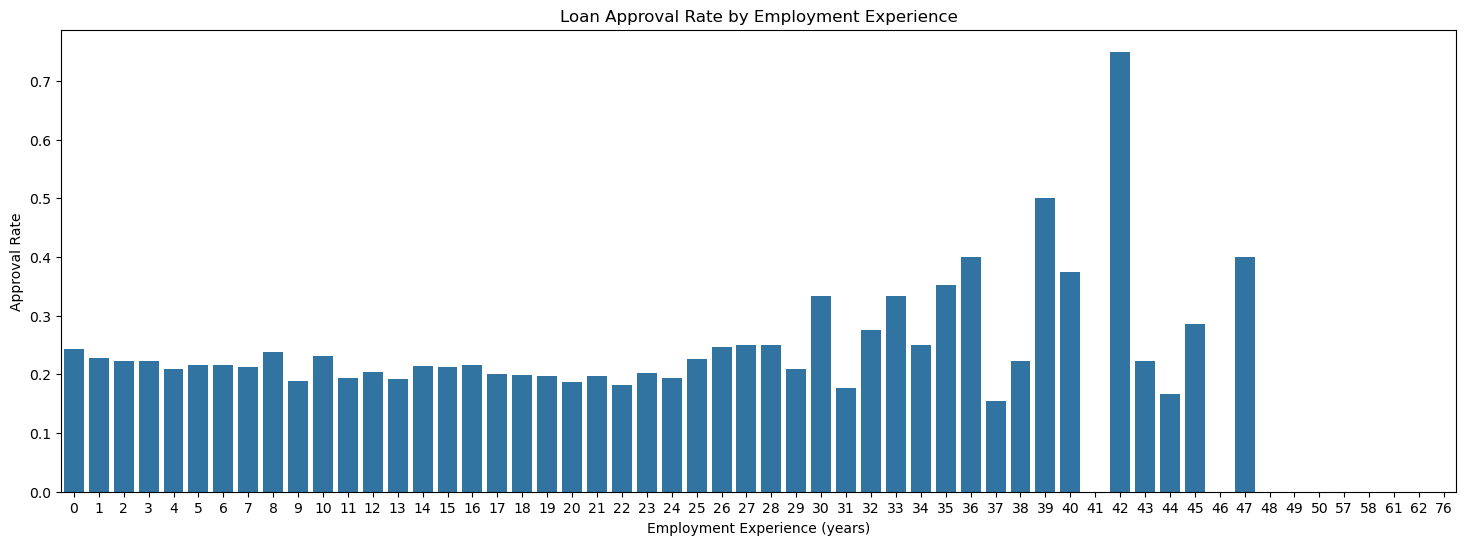

In [65]:
# Loan Approval Rate by Employment Experience

plt.figure(figsize=(18, 6))

sns.barplot(x='person_emp_exp', y='loan_status', data=data, ci=None)

plt.title('Loan Approval Rate by Employment Experience')

plt.xlabel('Employment Experience (years)')

plt.ylabel('Approval Rate')

plt.show()

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\4162709962.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='person_emp_exp', y='loan_status', data=filtered_data, ci=None)


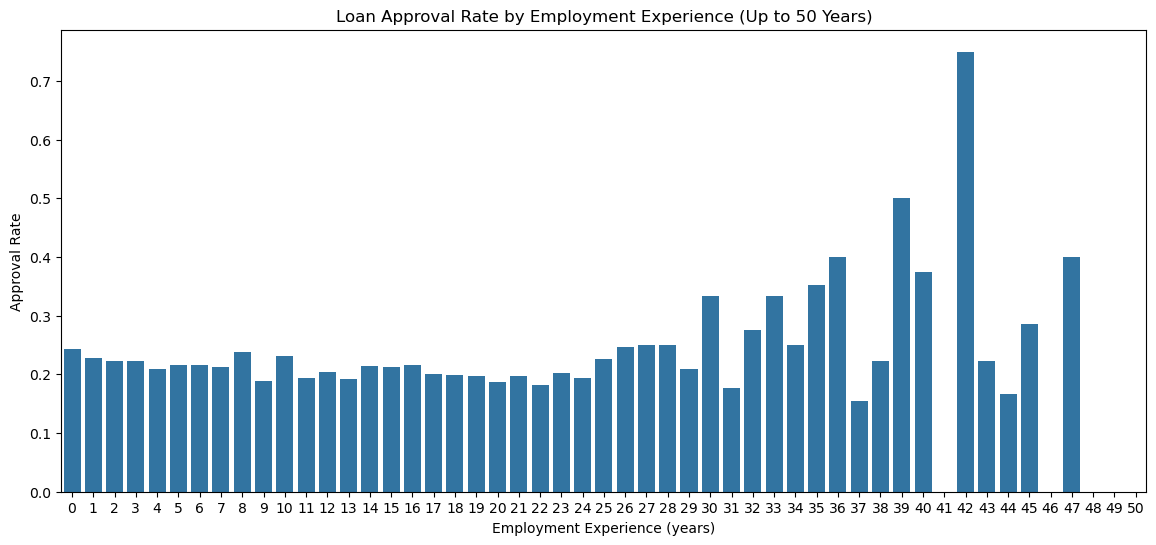

In [67]:
# Filter the dataset to include only rows where person_emp_exp is less than or equal to 50

filtered_data = data[data['person_emp_exp'] <= 50]



# Create the barplot for loan approval rate by employment experience (up to 50 years)

plt.figure(figsize=(14, 6))

sns.barplot(x='person_emp_exp', y='loan_status', data=filtered_data, ci=None)

plt.title('Loan Approval Rate by Employment Experience (Up to 50 Years)')

plt.xlabel('Employment Experience (years)')

plt.ylabel('Approval Rate')

plt.show()


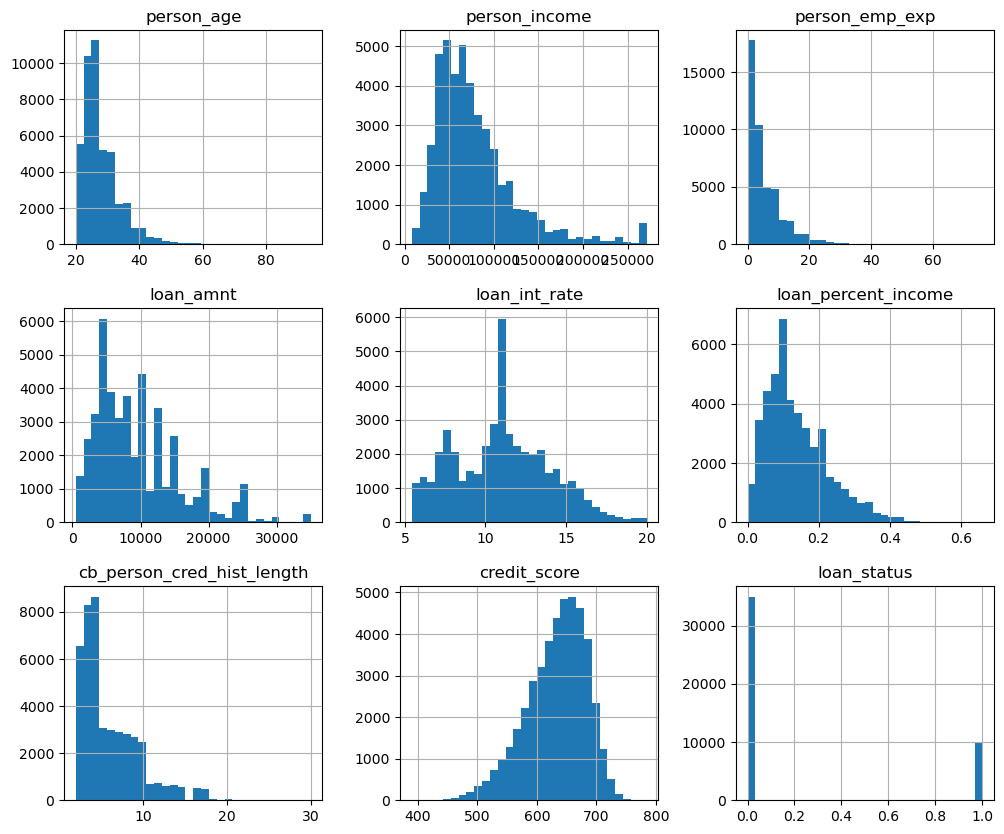

In [69]:
data[num_cols].hist(bins=30, figsize=(12,10))
plt.show()

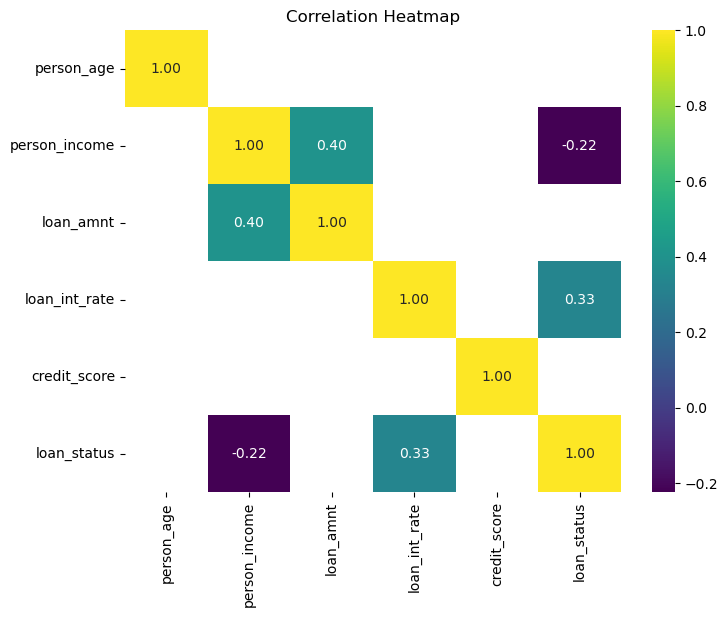

In [71]:
# Select only relevant numerical columns
columns_to_include = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 
                      'credit_score', 'loan_status']
filtered_data = data[columns_to_include]

# Compute the correlation matrix
corr_matrix = filtered_data.corr()

# Filter correlations above a certain threshold
threshold = 0.2
filtered_corr = corr_matrix[(corr_matrix >= threshold) | (corr_matrix <= -threshold)]

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap="viridis", cbar=True, mask=filtered_corr.isnull())
plt.title("Correlation Heatmap")
plt.show()

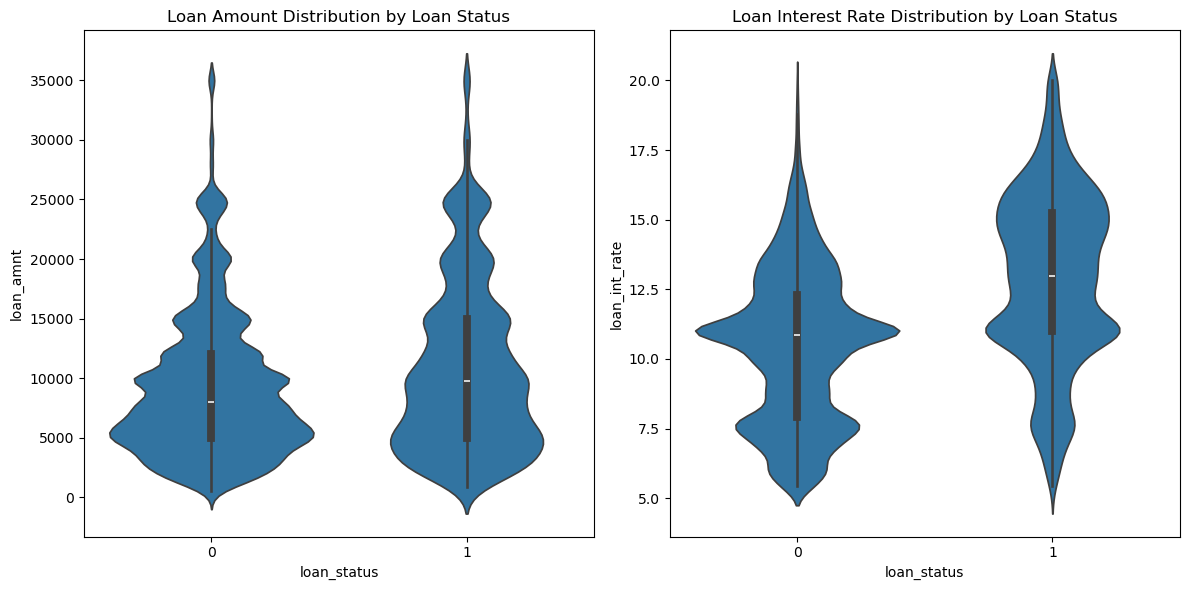

In [73]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='loan_status', y='loan_amnt', data=data)
plt.title('Loan Amount Distribution by Loan Status')

plt.subplot(1, 2, 2)
sns.violinplot(x='loan_status', y='loan_int_rate', data=data)
plt.title('Loan Interest Rate Distribution by Loan Status')

plt.tight_layout()
plt.show()

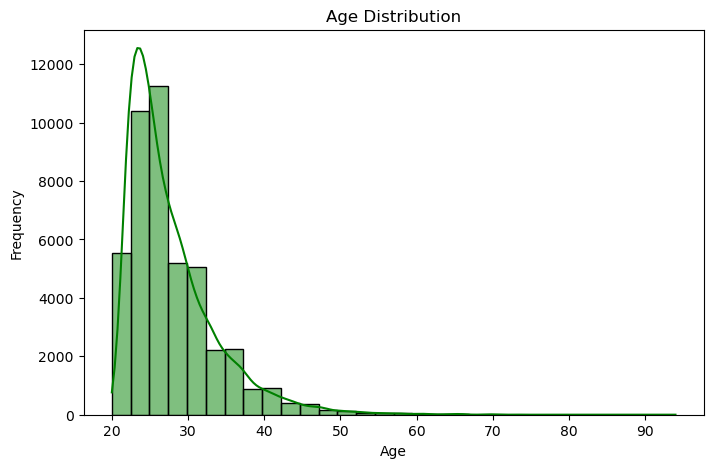

In [75]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['person_age'], kde=True, bins=30, color='green')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

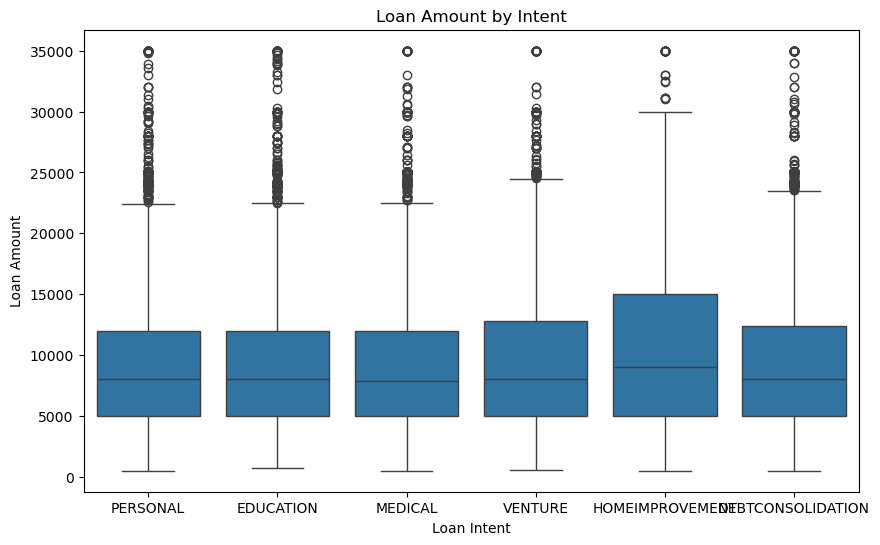

In [77]:
# Loan Amount by Intent
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='loan_intent', y='loan_amnt')
plt.title("Loan Amount by Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Loan Amount")
plt.show()

C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\1576179944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='loan_status', y='credit_score', palette='Set3')


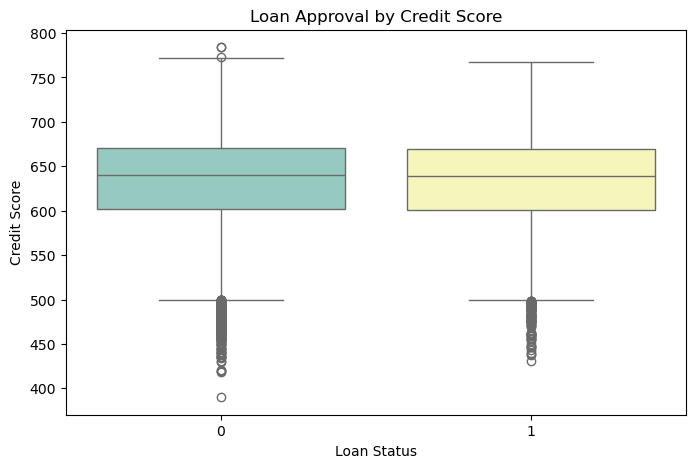

In [79]:
# Loan Approval by Credit Score
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='loan_status', y='credit_score', palette='Set3')
plt.title("Loan Approval by Credit Score")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.show()

In [81]:
# Mock auxiliary dataset to demonstrate merging
aux_data = pd.DataFrame({
    'person_id': range(1, 11),
    'extra_info': ['Info' + str(i) for i in range(1, 11)]
})

# Add a `person_id` column to the main dataset
data['person_id'] = range(1, len(data) + 1)

# Merge datasets
merged_data = pd.merge(data, aux_data, on='person_id', how='left')
print(merged_data.head())

   person_age  person_gender person_education  person_income  person_emp_exp  \
0          22              0           Master        71948.0               0   
1          21              0      High School        12282.0               0   
2          25              0      High School        12438.0               3   
3          23              0         Bachelor        79753.0               0   
4          24              1           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0          

In [83]:
data

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,age_category,person_id
0,22,0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1,teen,1
1,21,0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0,teen,2
2,25,0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1,teen,3
3,23,0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1,teen,4
4,24,1,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1,teen,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,0,1,adult,44989
44996,37,0,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,0,1,mature adult,44990
44997,33,1,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,0,1,adult,44991
44998,29,1,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,0,1,adult,44992


In [85]:
# Features and target variable
X = data.drop(columns=['loan_status', 'person_id'])
y = data['loan_status']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [87]:
# Identify categorical and numeric columns
categorical_cols = ['person_education', 'person_home_ownership', 'loan_intent', 'age_category']
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# One-Hot Encode Categorical Columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns of training and test sets to ensure consistency
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [89]:
# # Train Logistic Regression
# log_reg = LogisticRegression()
# log_reg.fit(X_train, y_train)

# # Predict with Logistic Regression
# y_pred_log = log_reg.predict(X_test)

# Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_encoded, y_train)

# Predict with Logistic Regression
y_pred_log = log_reg.predict(X_test_encoded)

C:\Users\abiyu\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [91]:
# Evaluate Logistic Regression
print("Logistic Regression - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nLogistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_log))

print("\nLogistic Regression - Accuracy Score:")
print(accuracy_score(y_test, y_pred_log))

Logistic Regression - Confusion Matrix:
[[6639  363]
 [1206  791]]

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.89      7002
           1       0.69      0.40      0.50      1997

    accuracy                           0.83      8999
   macro avg       0.77      0.67      0.70      8999
weighted avg       0.81      0.83      0.81      8999


Logistic Regression - Accuracy Score:
0.8256472941437938


In [93]:
# Train Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train_encoded, y_train)

# Predict with Decision Tree
y_pred_tree = decision_tree.predict(X_test_encoded)

In [95]:
# Evaluate Decision Tree
print("Decision Tree - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nDecision Tree - Classification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nDecision Tree - Accuracy Score:")
print(accuracy_score(y_test, y_pred_tree))

Decision Tree - Confusion Matrix:
[[6529  473]
 [ 418 1579]]

Decision Tree - Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7002
           1       0.77      0.79      0.78      1997

    accuracy                           0.90      8999
   macro avg       0.85      0.86      0.86      8999
weighted avg       0.90      0.90      0.90      8999


Decision Tree - Accuracy Score:
0.9009889987776419


In [97]:
# Train Random Forest
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train_encoded, y_train)

# Predict with Random Forest
y_pred_rf = random_forest.predict(X_test_encoded)

In [99]:
# Evaluate Random Forest
print("Random Forest - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest - Accuracy Score:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest - Confusion Matrix:
[[6831  171]
 [ 470 1527]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7002
           1       0.90      0.76      0.83      1997

    accuracy                           0.93      8999
   macro avg       0.92      0.87      0.89      8999
weighted avg       0.93      0.93      0.93      8999


Random Forest - Accuracy Score:
0.9287698633181465


In [101]:
# Train Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_encoded, y_train)

# Predict with Linear Regression
y_pred_linear = linear_reg.predict(X_test_encoded)

# Convert predictions to binary (1/0) using 0.5 threshold
y_pred_linear_binary = (y_pred_linear >= 0.5).astype(int)

In [103]:
# Evaluate Linear Regression
mse = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression - Mean Squared Error: {mse}")

print("\nLinear Regression - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear_binary))

print("\nLinear Regression - Accuracy Score:")
print(accuracy_score(y_test, y_pred_linear_binary))

Linear Regression - Mean Squared Error: 0.0907191355360154

Linear Regression - Confusion Matrix:
[[6701  301]
 [ 641 1356]]

Linear Regression - Accuracy Score:
0.8953217024113791


In [105]:
# Create a performance summary
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Linear Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_linear_binary),
    ]
}

results_df = pd.DataFrame(results)

# Display results
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.825647
1        Decision Tree  0.900989
2        Random Forest  0.928770
3    Linear Regression  0.895322


C:\Users\abiyu\AppData\Local\Temp\ipykernel_12900\3135073324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="coolwarm")


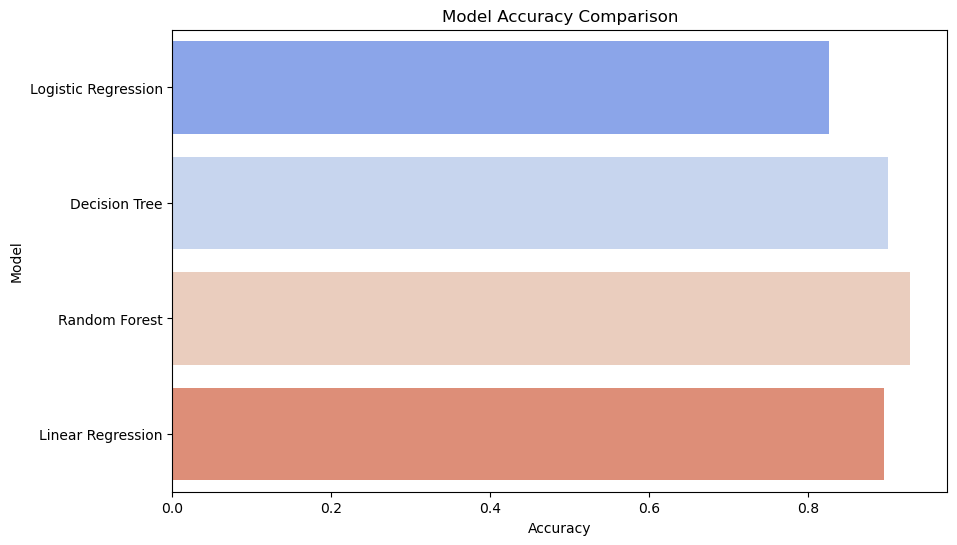

In [107]:
# Plot results
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="coolwarm")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
UNSUPERVISED LEARNING

C:\Users\abiyu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abiyu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\abiyu\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\abiyu\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\abiyu\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

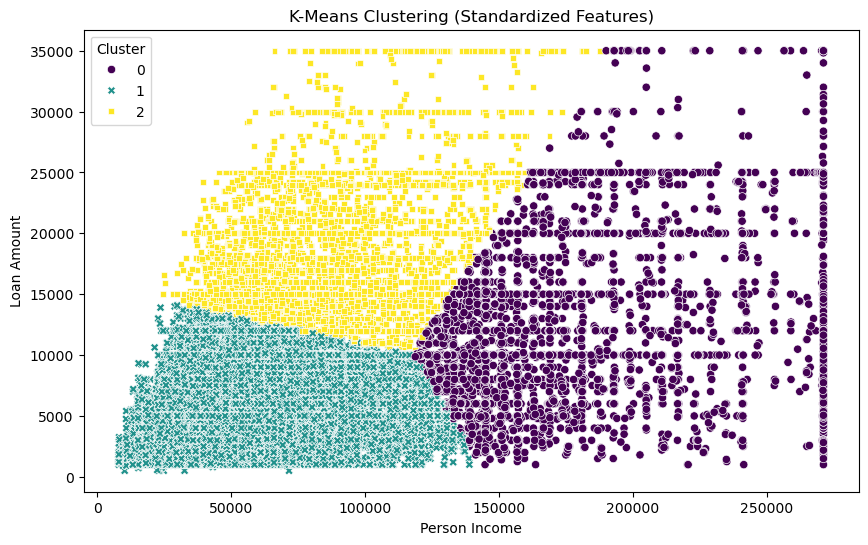

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numerical features for clustering
X_clustering = filtered_data[['person_income', 'loan_amnt']]

# Standardize the features
scaler = StandardScaler()
X_clustering_scaled = scaler.fit_transform(X_clustering)

# Fit K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)
filtered_data['Cluster'] = kmeans.fit_predict(X_clustering_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_clustering['person_income'], 
    y=X_clustering['loan_amnt'], 
    hue=filtered_data['Cluster'], 
    palette="viridis", 
    style=filtered_data['Cluster']
)
plt.title("K-Means Clustering (Standardized Features)")
plt.xlabel("Person Income")
plt.ylabel("Loan Amount")
plt.show()

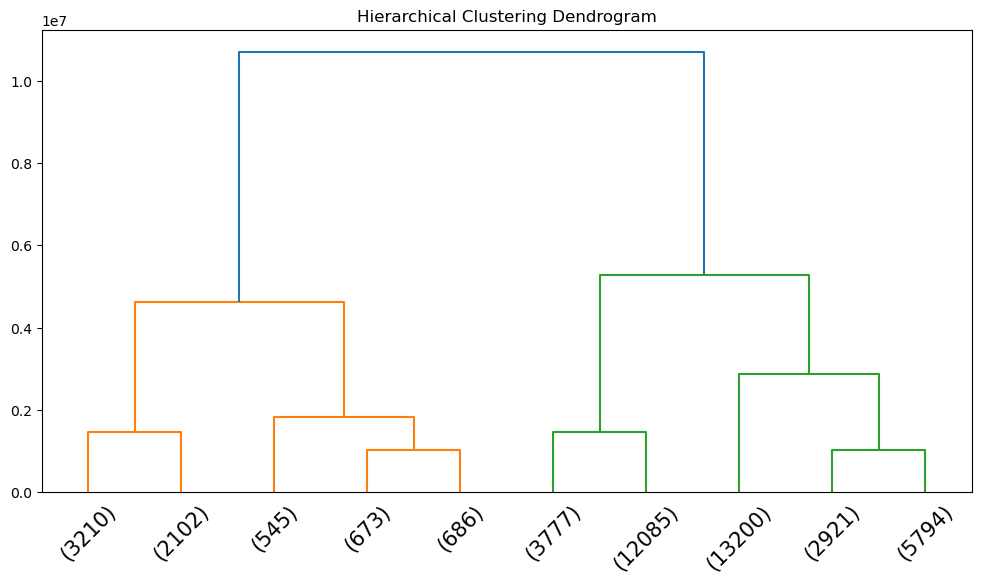

In [111]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
linkage_matrix = linkage(X_clustering, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=10, leaf_rotation=45, leaf_font_size=15)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()